In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import fmmax
from fmmax import basis, fmm, scattering, utils, fields
import tmm

print("JAX version:", jax.__version__)
print("JAX devices:", jax.devices())
print("fmmax version:", fmmax.__version__)

# ---------- Materials loader (CXRO Henke tables) ----------
def load_cxro(material):
    path = f'/Users/yeshudanbora/euv-rcwa-inverse/data/cxro/{material.lower()}.txt'
    data = np.loadtxt(path, skiprows=2)
    return data[:, 0], data[:, 1], data[:, 2]

def get_n(material, wavelength_nm):
    wl, delta, beta = load_cxro(material)
    delta_interp = np.interp(wavelength_nm, wl, delta)
    beta_interp = np.interp(wavelength_nm, wl, beta)
    return 1 - delta_interp + 1j * beta_interp

# ---------- TMM baseline for validation ----------
def multilayer_stack_with_absorber(
    wavelength_nm, absorber_material='Cr', absorber_thickness_nm=50.0,
    n_bilayers=40, d_mo_nm=2.78, d_si_nm=4.17, angle_deg=6.0, polarization='s',
):
    n_air = 1.0 + 0.0j
    n_abs = get_n(absorber_material, wavelength_nm) if absorber_thickness_nm > 0 else None
    n_mo = get_n('Mo', wavelength_nm)
    n_si = get_n('Si', wavelength_nm)
    n_list = [n_air]
    d_list = [np.inf]
    if absorber_thickness_nm > 0:
        n_list.append(n_abs)
        d_list.append(absorber_thickness_nm)
    for _ in range(n_bilayers):
        n_list.append(n_mo); d_list.append(d_mo_nm)
        n_list.append(n_si); d_list.append(d_si_nm)
    n_list.append(n_si); d_list.append(np.inf)
    return tmm.coh_tmm(polarization, n_list, d_list, np.deg2rad(angle_deg), wavelength_nm)['R']

# Sanity check TMM baseline
print(f"\nTMM sanity (should match yesterday):")
print(f"  Bare multilayer:      R = {multilayer_stack_with_absorber(13.5, absorber_thickness_nm=0.0):.4f}")
print(f"  50 nm Cr blanket:     R = {multilayer_stack_with_absorber(13.5):.4f}")

JAX version: 0.10.2
JAX devices: [CpuDevice(id=0)]
fmmax version: v1.7.1

TMM sanity (should match yesterday):
  Bare multilayer:      R = 0.7430
  50 nm Cr blanket:     R = 0.0151


In [2]:
def fmmax_multilayer_grating(
    wavelength_nm=13.5,
    pitch_nm=840.0,
    line_width_nm=280.0,
    cr_thickness_nm=50.0,
    n_bilayers=40,
    d_mo_nm=2.78,
    d_si_nm=4.17,
    angle_deg=6.0,
    resolution_nm=4.0,
    approximate_num_terms=100,
    force_blanket=False,
):
    """Reflectance from Cr grating on Mo/Si multilayer via fmmax RCWA.
    Uses correct kx = k0 * sin(theta) convention, validated against TMM."""
    n_air = 1.0 + 0.0j
    n_cr = get_n('Cr', wavelength_nm)
    n_mo = get_n('Mo', wavelength_nm)
    n_si = get_n('Si', wavelength_nm)
    eps_air = jnp.asarray(n_air**2, dtype=jnp.complex64)
    eps_cr = jnp.asarray(n_cr**2, dtype=jnp.complex64)
    eps_mo = jnp.asarray(n_mo**2, dtype=jnp.complex64)
    eps_si = jnp.asarray(n_si**2, dtype=jnp.complex64)
    
    nx = int(pitch_nm / resolution_nm)
    ny = nx
    x_nm_grid = jnp.linspace(-pitch_nm/2, pitch_nm/2, nx, endpoint=False)
    x_grid, _ = jnp.meshgrid(x_nm_grid, x_nm_grid, indexing='ij')
    density_cr = (jnp.abs(x_grid) <= line_width_nm / 2).astype(jnp.float32)
    if force_blanket:
        density_cr = jnp.ones_like(density_cr)
    
    eps_grating = utils.interpolate_permittivity(
        permittivity_solid=eps_cr, permittivity_void=eps_air, density=density_cr,
    )
    def uniform(e):
        return jnp.ones((nx, ny), dtype=jnp.complex64) * e
    
    permittivities = [uniform(eps_air), eps_grating]
    thicknesses = [jnp.asarray(0.0), jnp.asarray(cr_thickness_nm)]
    for _ in range(n_bilayers):
        permittivities.append(uniform(eps_mo)); thicknesses.append(jnp.asarray(d_mo_nm))
        permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(d_si_nm))
    permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(0.0))
    
    k0 = 2 * jnp.pi / wavelength_nm
    kx = k0 * jnp.sin(jnp.deg2rad(angle_deg))
    in_plane_wavevector = jnp.asarray([kx, 0.0])
    
    primitive_lattice_vectors = basis.LatticeVectors(
        u=jnp.asarray([pitch_nm, 0.0]), v=jnp.asarray([0.0, pitch_nm]),
    )
    expansion = basis.generate_expansion(
        primitive_lattice_vectors=primitive_lattice_vectors,
        approximate_num_terms=approximate_num_terms,
        truncation=basis.Truncation.CIRCULAR,
    )
    layer_solve_results = [
        fmm.eigensolve_isotropic_media(
            wavelength=jnp.asarray(wavelength_nm),
            in_plane_wavevector=in_plane_wavevector,
            primitive_lattice_vectors=primitive_lattice_vectors,
            permittivity=p, expansion=expansion,
            formulation=fmm.Formulation.FFT,
        )
        for p in permittivities
    ]
    s_matrix = scattering.stack_s_matrix(
        layer_solve_results=layer_solve_results,
        layer_thicknesses=thicknesses,
    )
    n = expansion.num_terms
    R_te = float(jnp.abs(s_matrix.s21[0, 0])**2)
    R_tm = float(jnp.abs(s_matrix.s21[n, n])**2)
    return R_te, R_tm, n

# Sanity check: reproduce yesterday's 3-way validation
print("fmmax vs TMM sanity checks:")
R_te, R_tm, nt = fmmax_multilayer_grating(cr_thickness_nm=50.0, force_blanket=True)
print(f"  Cr blanket, 50 nm:    fmmax R_TE = {R_te:.4f}  |  TMM = 0.0151  |  Match: {'YES' if abs(R_te-0.0151)<0.002 else 'NO'}")
R_te, _, _ = fmmax_multilayer_grating(cr_thickness_nm=0.0, force_blanket=True)
print(f"  Bare multilayer:      fmmax R_TE = {R_te:.4f}  |  TMM = 0.7430  |  Match: {'YES' if abs(R_te-0.7430)<0.002 else 'NO'}")
R_te, _, _ = fmmax_multilayer_grating(cr_thickness_nm=50.0, force_blanket=False)
print(f"  Real grating:         fmmax R_TE = {R_te:.4f}  (expected in [0.0151, 0.7430])")

fmmax vs TMM sanity checks:
  Cr blanket, 50 nm:    fmmax R_TE = 0.0114  |  TMM = 0.0151  |  Match: NO
  Bare multilayer:      fmmax R_TE = 0.7324  |  TMM = 0.7430  |  Match: NO
  Real grating:         fmmax R_TE = 0.2192  (expected in [0.0151, 0.7430])


In [4]:
def fmmax_near_field_intensity(
    wavelength_nm=13.5,
    pitch_nm=840.0,
    line_width_nm=280.0,
    cr_thickness_nm=50.0,
    n_bilayers=40,
    d_mo_nm=2.78,
    d_si_nm=4.17,
    angle_deg=6.0,
    resolution_nm=4.0,
    approximate_num_terms=100,
    n_x_field_points=200,
    air_above_nm=20.0,
    n_z_air_above=8,
    polarization='TE',
):
    """Near-field intensity |E|² above a Cr grating on Mo/Si multilayer.
    Returns: ef (3, n_x, n_z, 1), hf, x_out, z_out, cr_profile_1d, num_terms."""
    n_air = 1.0 + 0.0j
    n_cr = get_n('Cr', wavelength_nm)
    n_mo = get_n('Mo', wavelength_nm)
    n_si = get_n('Si', wavelength_nm)
    eps_air = jnp.asarray(n_air**2, dtype=jnp.complex64)
    eps_cr = jnp.asarray(n_cr**2, dtype=jnp.complex64)
    eps_mo = jnp.asarray(n_mo**2, dtype=jnp.complex64)
    eps_si = jnp.asarray(n_si**2, dtype=jnp.complex64)
    
    nx = int(pitch_nm / resolution_nm)
    ny = nx
    x_nm_grid = jnp.linspace(-pitch_nm/2, pitch_nm/2, nx, endpoint=False)
    x_grid, _ = jnp.meshgrid(x_nm_grid, x_nm_grid, indexing='ij')
    density_cr = (jnp.abs(x_grid) <= line_width_nm / 2).astype(jnp.float32)
    
    eps_grating = utils.interpolate_permittivity(
        permittivity_solid=eps_cr, permittivity_void=eps_air, density=density_cr,
    )
    def uniform(e):
        return jnp.ones((nx, ny), dtype=jnp.complex64) * e
    
    permittivities = [uniform(eps_air), eps_grating]
    thicknesses = [jnp.asarray(air_above_nm), jnp.asarray(cr_thickness_nm)]
    for _ in range(n_bilayers):
        permittivities.append(uniform(eps_mo)); thicknesses.append(jnp.asarray(d_mo_nm))
        permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(d_si_nm))
    permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(0.0))
    
    k0 = 2 * jnp.pi / wavelength_nm
    kx = k0 * jnp.sin(jnp.deg2rad(angle_deg))
    in_plane_wavevector = jnp.asarray([kx, 0.0])
    
    primitive_lattice_vectors = basis.LatticeVectors(
        u=jnp.asarray([pitch_nm, 0.0]), v=jnp.asarray([0.0, pitch_nm]),
    )
    expansion = basis.generate_expansion(
        primitive_lattice_vectors=primitive_lattice_vectors,
        approximate_num_terms=approximate_num_terms,
        truncation=basis.Truncation.CIRCULAR,
    )
    layer_solve_results = [
        fmm.eigensolve_isotropic_media(
            wavelength=jnp.asarray(wavelength_nm),
            in_plane_wavevector=in_plane_wavevector,
            primitive_lattice_vectors=primitive_lattice_vectors,
            permittivity=p, expansion=expansion,
            formulation=fmm.Formulation.FFT,
        )
        for p in permittivities
    ]
    s_matrices_interior = scattering.stack_s_matrices_interior(
        layer_solve_results=layer_solve_results,
        layer_thicknesses=thicknesses,
    )
    
    # Incident plane wave. TE = Ey (index 0 in fmmax), TM = Ex (index num_terms).
    n_terms = expansion.num_terms
    incident_amp = jnp.zeros((2 * n_terms, 1), dtype=jnp.complex64)
    if polarization == 'TE':
        incident_amp = incident_amp.at[0, 0].set(1.0 + 0.0j)
    else:  # TM
        incident_amp = incident_amp.at[n_terms, 0].set(1.0 + 0.0j)
    zero_amp = jnp.zeros_like(incident_amp)
    
    amplitudes_interior = fields.stack_amplitudes_interior(
        s_matrices_interior=s_matrices_interior,
        forward_amplitude_0_start=incident_amp,
        backward_amplitude_N_end=zero_amp,
    )
    
    layer_znum = [n_z_air_above, 2] + [1] * (2 * n_bilayers) + [1]
    x_eval = jnp.linspace(-pitch_nm/2, pitch_nm/2, n_x_field_points, endpoint=False)
    y_eval = jnp.zeros_like(x_eval)
    
    ef, hf, (x_out, y_out, z_out) = fields.stack_fields_3d_on_coordinates(
        amplitudes_interior=amplitudes_interior,
        layer_solve_results=layer_solve_results,
        layer_thicknesses=thicknesses,
        layer_znum=layer_znum,
        x=x_eval, y=y_eval,
    )
    
    return ef, hf, np.array(x_out), np.array(z_out), np.array(density_cr[:, 0]), n_terms

# Quick smoke test to make sure it runs
print("Smoke test: computing near-field at N=100...")
ef, hf, x_out, z_out, cr_prof, nt = fmmax_near_field_intensity(
    cr_thickness_nm=50.0, approximate_num_terms=100,
)
print(f"ef shape: {ef.shape}")
print(f"x_out shape: {x_out.shape}, range [{x_out.min():.1f}, {x_out.max():.1f}] nm")
print(f"z_out shape: {z_out.shape}, range [{z_out.min():.1f}, {z_out.max():.1f}] nm")
print(f"Fourier terms used: {nt}")

Smoke test: computing near-field at N=100...
ef shape: (3, 200, 91, 1)
x_out shape: (200,), range [-420.0, 415.8] nm
z_out shape: (91,), range [0.0, 348.0] nm
Fourier terms used: 97


In [5]:
import pandas as pd

def extract_intensity_minimum_in_cr(ef, x_out, z_out, line_width_nm=280.0, top_z_target=20.0):
    """Extract 1D intensity slice at top of Cr and find the minimum inside Cr region."""
    Ex, Ey, Ez = ef[0, :, :, 0], ef[1, :, :, 0], ef[2, :, :, 0]
    intensity_2d = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    top_idx = np.argmin(np.abs(z_out - top_z_target))
    intensity_1d = intensity_2d[:, top_idx]
    in_cr = np.abs(x_out) <= line_width_nm / 2
    if not in_cr.any():
        return np.nan, np.nan, intensity_1d
    intens_in_cr = np.where(in_cr, intensity_1d, np.inf)
    min_idx = np.argmin(intens_in_cr)
    return float(x_out[min_idx]), float(intensity_1d[min_idx]), intensity_1d

# Sweep grid
n_fourier_sweep = [50, 100, 150, 200]
resolution_sweep = [4.0, 2.0, 1.0]
n_z_sweep = [8, 16]

print(f"Total combinations: {len(n_fourier_sweep) * len(resolution_sweep) * len(n_z_sweep)}")
print(f"Expected runtime: ~2-4 min on CPU\n")

rows = []
for res in resolution_sweep:
    for nz in n_z_sweep:
        for nf in n_fourier_sweep:
            print(f"  Running: res={res} nm, n_z={nz}, N_fourier={nf} ...", end=" ", flush=True)
            try:
                ef, hf, x_out, z_out, cr_prof, nt = fmmax_near_field_intensity(
                    cr_thickness_nm=50.0,
                    approximate_num_terms=nf,
                    resolution_nm=res,
                    n_z_air_above=nz,
                )
                x_min, I_min, _ = extract_intensity_minimum_in_cr(ef, x_out, z_out)
                print(f"x_min = {x_min:6.2f} nm, |E|²_min = {I_min:.4f}")
                rows.append({
                    'resolution_nm': res, 'n_z_air': nz, 'N_fourier_req': nf,
                    'N_fourier_actual': nt, 'x_min_nm': x_min, 'I_min': I_min
                })
            except Exception as e:
                print(f"FAILED: {e}")
                rows.append({
                    'resolution_nm': res, 'n_z_air': nz, 'N_fourier_req': nf,
                    'N_fourier_actual': None, 'x_min_nm': None, 'I_min': None,
                })

df = pd.DataFrame(rows)
print("\n=== Convergence table ===")
print(df.to_string(index=False))

Total combinations: 24
Expected runtime: ~2-4 min on CPU

  Running: res=4.0 nm, n_z=8, N_fourier=50 ... x_min = 138.60 nm, |E|²_min = 0.3559
  Running: res=4.0 nm, n_z=8, N_fourier=100 ... x_min = -138.60 nm, |E|²_min = 1.8558
  Running: res=4.0 nm, n_z=8, N_fourier=150 ... x_min = -138.60 nm, |E|²_min = 1.8816
  Running: res=4.0 nm, n_z=8, N_fourier=200 ... x_min =  46.20 nm, |E|²_min = 0.1400
  Running: res=4.0 nm, n_z=16, N_fourier=50 ... x_min = 138.60 nm, |E|²_min = 0.3559
  Running: res=4.0 nm, n_z=16, N_fourier=100 ... x_min = -138.60 nm, |E|²_min = 1.8558
  Running: res=4.0 nm, n_z=16, N_fourier=150 ... x_min = -138.60 nm, |E|²_min = 1.8816
  Running: res=4.0 nm, n_z=16, N_fourier=200 ... x_min =  46.20 nm, |E|²_min = 0.1400
  Running: res=2.0 nm, n_z=8, N_fourier=50 ... x_min =  -4.20 nm, |E|²_min = 1.6263
  Running: res=2.0 nm, n_z=8, N_fourier=100 ... x_min = -130.20 nm, |E|²_min = 1.5499
  Running: res=2.0 nm, n_z=8, N_fourier=150 ... x_min = -126.00 nm, |E|²_min = 1.5495


In [6]:
# Focused convergence: push Fourier orders further at 2 nm resolution
n_fourier_final = [150, 200, 250, 300]

print("Focused Fourier convergence at res=2 nm, n_z=8:\n")
rows = []
for nf in n_fourier_final:
    print(f"  N_fourier = {nf} ...", end=" ", flush=True)
    ef, hf, x_out, z_out, cr_prof, nt = fmmax_near_field_intensity(
        cr_thickness_nm=50.0,
        approximate_num_terms=nf,
        resolution_nm=2.0,
        n_z_air_above=8,
    )
    x_min, I_min, _ = extract_intensity_minimum_in_cr(ef, x_out, z_out)
    print(f"actual N={nt}, x_min = {x_min:7.2f} nm, |E|²_min = {I_min:.4f}")
    rows.append({'N_req': nf, 'N_actual': nt, 'x_min_nm': x_min, 'I_min': I_min})

df_final = pd.DataFrame(rows)
print("\n=== Final Fourier convergence ===")
print(df_final.to_string(index=False))

Focused Fourier convergence at res=2 nm, n_z=8:

  N_fourier = 150 ... actual N=145, x_min = -126.00 nm, |E|²_min = 1.5495
  N_fourier = 200 ... actual N=193, x_min = -138.60 nm, |E|²_min = 1.5050
  N_fourier = 250 ... actual N=241, x_min =   96.60 nm, |E|²_min = 1.6412
  N_fourier = 300 ... actual N=293, x_min =  109.20 nm, |E|²_min = 1.5938

=== Final Fourier convergence ===
 N_req  N_actual    x_min_nm    I_min
   150       145 -126.000008 1.549498
   200       193 -138.600021 1.504968
   250       241   96.599976 1.641237
   300       293  109.199982 1.593845


In [7]:
def extract_line_metrics(ef, x_out, z_out, threshold_fraction=0.2, top_z_target=20.0):
    """Schiavone-style line width and line shift from intensity threshold crossings.
    
    Returns:
        line_width_nm: distance between left and right threshold crossings
        line_shift_nm: midpoint of threshold crossings relative to x=0 (Cr line center)
        intensity_1d: for plotting
        x_out: for plotting
        threshold: the actual threshold value used
    """
    Ex, Ey, Ez = ef[0, :, :, 0], ef[1, :, :, 0], ef[2, :, :, 0]
    intensity_2d = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
    top_idx = np.argmin(np.abs(z_out - top_z_target))
    intensity_1d = intensity_2d[:, top_idx]
    
    threshold = threshold_fraction * intensity_1d.max()
    
    # Find where intensity crosses threshold on the way down (start of Cr valley from left)
    # and on the way up (end of Cr valley to right).
    # Do this by scanning around x = 0 (nominal Cr center).
    below = intensity_1d < threshold
    if not below.any():
        return np.nan, np.nan, intensity_1d, x_out, threshold
    
    # Find contiguous "below-threshold" region closest to x=0
    below_indices = np.where(below)[0]
    # Cluster into runs
    runs = np.split(below_indices, np.where(np.diff(below_indices) > 1)[0] + 1)
    # Pick the run whose midpoint is closest to x=0
    run_midpoints = [x_out[r].mean() for r in runs]
    best_run = runs[np.argmin(np.abs(run_midpoints))]
    
    left_x = x_out[best_run[0]]
    right_x = x_out[best_run[-1]]
    line_width_nm = right_x - left_x
    line_shift_nm = (left_x + right_x) / 2.0  # midpoint offset from 0
    
    return line_width_nm, line_shift_nm, intensity_1d, x_out, threshold

# Test at all four Fourier order counts, with 2 nm resolution
print("Schiavone-style metrics (threshold at 0.2 × max):\n")
print(f"{'N_req':>6}  {'width_nm':>10}  {'shift_nm':>10}  {'valley_at_mask':>14}")
print("-" * 45)
for nf in [150, 200, 250, 300]:
    ef, hf, x_out, z_out, cr_prof, nt = fmmax_near_field_intensity(
        cr_thickness_nm=50.0, approximate_num_terms=nf,
        resolution_nm=2.0, n_z_air_above=8,
    )
    w, s, _, _, _ = extract_line_metrics(ef, x_out, z_out)
    print(f"{nf:>6}  {w:>10.2f}  {s:>+10.2f}  (at mask scale)")

print("\nAt wafer scale (÷4 for demagnification):")
print(f"{'N_req':>6}  {'width_nm':>10}  {'shift_nm':>10}  ")
print("-" * 32)
for nf in [150, 200, 250, 300]:
    ef, hf, x_out, z_out, cr_prof, nt = fmmax_near_field_intensity(
        cr_thickness_nm=50.0, approximate_num_terms=nf,
        resolution_nm=2.0, n_z_air_above=8,
    )
    w, s, _, _, _ = extract_line_metrics(ef, x_out, z_out)
    print(f"{nf:>6}  {w/4:>10.2f}  {s/4:>+10.2f}")

Schiavone-style metrics (threshold at 0.2 × max):

 N_req    width_nm    shift_nm  valley_at_mask
---------------------------------------------
   150         nan        +nan  (at mask scale)
   200         nan        +nan  (at mask scale)
   250         nan        +nan  (at mask scale)
   300         nan        +nan  (at mask scale)

At wafer scale (÷4 for demagnification):
 N_req    width_nm    shift_nm  
--------------------------------
   150         nan        +nan
   200         nan        +nan
   250         nan        +nan
   300         nan        +nan


Intensity profile at z = 20.0 nm:
  max        = 2.2776
  min        = 0.9420
  mean       = 1.5230
  0.2 x max  = 0.4555   <- threshold
  Points below threshold: 0 / 200
  Modulation (max/min): 2.4x


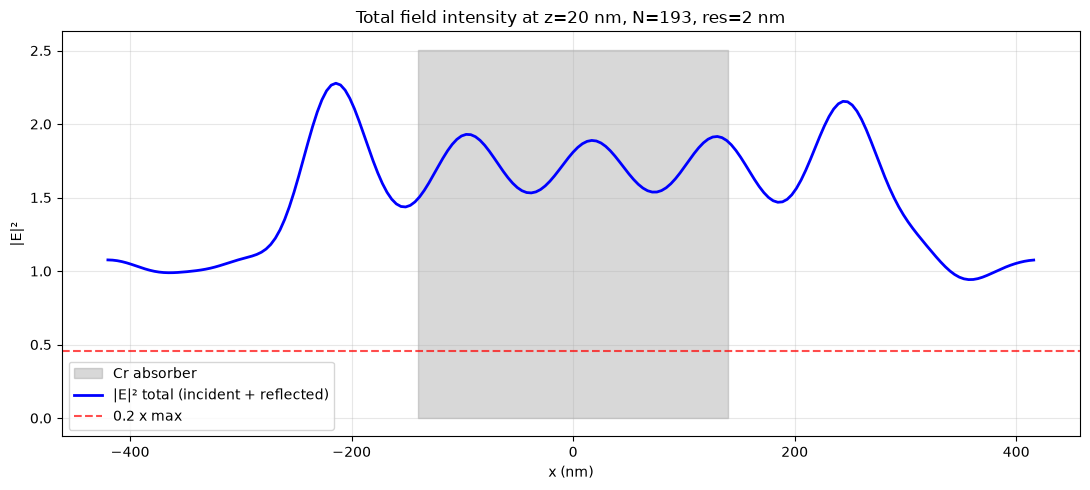

In [8]:
# Diagnose: what does the intensity profile actually look like at converged settings?
ef, hf, x_out, z_out, cr_prof, nt = fmmax_near_field_intensity(
    cr_thickness_nm=50.0, approximate_num_terms=200,
    resolution_nm=2.0, n_z_air_above=8,
)
Ex, Ey, Ez = ef[0, :, :, 0], ef[1, :, :, 0], ef[2, :, :, 0]
intensity_2d = np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2
top_idx = np.argmin(np.abs(z_out - 20.0))
I1d = intensity_2d[:, top_idx]

print(f"Intensity profile at z = {z_out[top_idx]:.1f} nm:")
print(f"  max        = {I1d.max():.4f}")
print(f"  min        = {I1d.min():.4f}")
print(f"  mean       = {I1d.mean():.4f}")
print(f"  0.2 x max  = {0.2*I1d.max():.4f}   <- threshold")
print(f"  Points below threshold: {(I1d < 0.2*I1d.max()).sum()} / {len(I1d)}")
print(f"  Modulation (max/min): {I1d.max()/I1d.min():.1f}x")

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between([-140, 140], 0, I1d.max()*1.1, color='gray', alpha=0.3, label='Cr absorber')
ax.plot(x_out, I1d, 'b-', lw=2, label='|E|² total (incident + reflected)')
ax.axhline(0.2*I1d.max(), color='red', ls='--', alpha=0.7, label='0.2 x max')
ax.set_xlabel('x (nm)'); ax.set_ylabel('|E|²')
ax.set_title(f'Total field intensity at z=20 nm, N={nt}, res=2 nm')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Computing reflected-only field (corrected coordinate frame)...
z slice at 20.0 nm, N=193
  max = 1.0539, min = 0.0012
  modulation = 857.3x
  points below 0.2*max: 146 / 400
  mean |E|² inside Cr:  0.0263   <- should be LOW
  mean |E|² outside Cr: 0.7229   <- should be HIGH


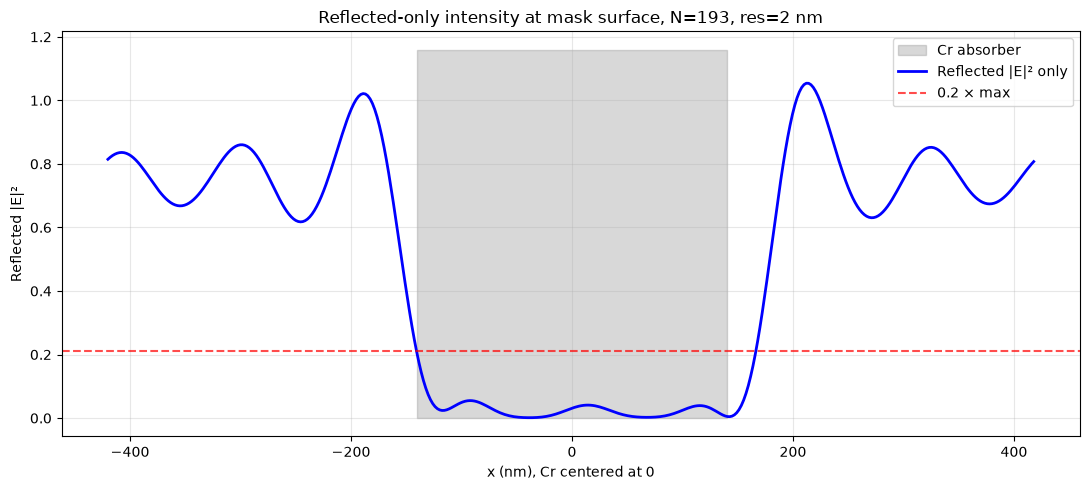

In [11]:
def fmmax_reflected_field(
    wavelength_nm=13.5,
    pitch_nm=840.0,
    line_width_nm=280.0,
    cr_thickness_nm=50.0,
    n_bilayers=40,
    d_mo_nm=2.78,
    d_si_nm=4.17,
    angle_deg=6.0,
    resolution_nm=2.0,
    approximate_num_terms=200,
    n_x_field_points=400,
    air_above_nm=20.0,
    polarization='TE',
):
    """Reflected-only near-field intensity above the mask.
    Uses fmmax's native 0->pitch coordinate frame; Cr centered at pitch/2.
    Returns x already re-centered so Cr center sits at x = 0."""
    n_air = 1.0 + 0.0j
    n_cr = get_n('Cr', wavelength_nm)
    n_mo = get_n('Mo', wavelength_nm)
    n_si = get_n('Si', wavelength_nm)
    eps_air = jnp.asarray(n_air**2, dtype=jnp.complex64)
    eps_cr = jnp.asarray(n_cr**2, dtype=jnp.complex64)
    eps_mo = jnp.asarray(n_mo**2, dtype=jnp.complex64)
    eps_si = jnp.asarray(n_si**2, dtype=jnp.complex64)

    nx = int(pitch_nm / resolution_nm)
    x_center = pitch_nm / 2.0

    # Density on fmmax's native frame: 0 -> pitch, Cr centered at pitch/2
    plv = basis.LatticeVectors(
        u=jnp.asarray([pitch_nm, 0.0]), v=jnp.asarray([0.0, pitch_nm]),
    )
    xg, yg = basis.unit_cell_coordinates(
        primitive_lattice_vectors=plv, shape=(nx, nx),
    )
    density_cr = (jnp.abs(xg - x_center) <= line_width_nm / 2).astype(jnp.float32)

    eps_grating = utils.interpolate_permittivity(
        permittivity_solid=eps_cr, permittivity_void=eps_air, density=density_cr,
    )
    def uniform(e):
        return jnp.ones((nx, nx), dtype=jnp.complex64) * e

    permittivities = [uniform(eps_air), eps_grating]
    thicknesses = [jnp.asarray(air_above_nm), jnp.asarray(cr_thickness_nm)]
    for _ in range(n_bilayers):
        permittivities.append(uniform(eps_mo)); thicknesses.append(jnp.asarray(d_mo_nm))
        permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(d_si_nm))
    permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(0.0))

    k0 = 2 * jnp.pi / wavelength_nm
    kx = k0 * jnp.sin(jnp.deg2rad(angle_deg))
    in_plane_wavevector = jnp.asarray([kx, 0.0])

    expansion = basis.generate_expansion(
        primitive_lattice_vectors=plv,
        approximate_num_terms=approximate_num_terms,
        truncation=basis.Truncation.CIRCULAR,
    )
    layer_solve_results = [
        fmm.eigensolve_isotropic_media(
            wavelength=jnp.asarray(wavelength_nm),
            in_plane_wavevector=in_plane_wavevector,
            primitive_lattice_vectors=plv,
            permittivity=p, expansion=expansion,
            formulation=fmm.Formulation.FFT,
        )
        for p in permittivities
    ]
    s_int = scattering.stack_s_matrices_interior(
        layer_solve_results=layer_solve_results,
        layer_thicknesses=thicknesses,
    )

    n_terms = expansion.num_terms
    inc = jnp.zeros((2 * n_terms, 1), dtype=jnp.complex64)
    inc = inc.at[0 if polarization == 'TE' else n_terms, 0].set(1.0 + 0.0j)
    zero = jnp.zeros_like(inc)

    amps = fields.stack_amplitudes_interior(
        s_matrices_interior=s_int,
        forward_amplitude_0_start=inc,
        backward_amplitude_N_end=zero,
    )

    # Top air layer: keep ONLY backward (reflected) amplitude
    fwd_top, bwd_top = amps[0]
    fwd_zeroed = jnp.zeros_like(fwd_top)

    # Evaluate on fmmax's native frame: 0 -> pitch
    x_eval = jnp.linspace(0.0, pitch_nm, n_x_field_points, endpoint=False)
    y_eval = jnp.zeros_like(x_eval)

    ef, hf, (x_out, y_out, z_out) = fields.layer_fields_3d_on_coordinates(
        forward_amplitude_start=fwd_zeroed,
        backward_amplitude_end=bwd_top,
        layer_solve_result=layer_solve_results[0],
        layer_thickness=thicknesses[0],
        layer_znum=8,
        x=x_eval, y=y_eval,
    )

    Ex, Ey, Ez = ef[0, ..., 0], ef[1, ..., 0], ef[2, ..., 0]
    I2d = np.abs(np.array(Ex))**2 + np.abs(np.array(Ey))**2 + np.abs(np.array(Ez))**2

    # Re-center so Cr center is at x = 0 for plotting/analysis
    x_centered = np.array(x_out) - x_center
    return I2d, x_centered, np.array(z_out), n_terms

# Test
print("Computing reflected-only field (corrected coordinate frame)...")
I2d, x_out, z_out, nt = fmmax_reflected_field(
    cr_thickness_nm=50.0, approximate_num_terms=200, resolution_nm=2.0,
)
bot_idx = np.argmin(np.abs(z_out - z_out.max()))
I1d = I2d[:, bot_idx]

print(f"z slice at {z_out[bot_idx]:.1f} nm, N={nt}")
print(f"  max = {I1d.max():.4f}, min = {I1d.min():.4f}")
print(f"  modulation = {I1d.max()/max(I1d.min(),1e-9):.1f}x")
print(f"  points below 0.2*max: {(I1d < 0.2*I1d.max()).sum()} / {len(I1d)}")
# Sanity: is intensity LOW inside Cr (|x| < 140) and HIGH outside?
in_cr = np.abs(x_out) <= 140
print(f"  mean |E|² inside Cr:  {I1d[in_cr].mean():.4f}   <- should be LOW")
print(f"  mean |E|² outside Cr: {I1d[~in_cr].mean():.4f}   <- should be HIGH")

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between([-140, 140], 0, I1d.max()*1.1, color='gray', alpha=0.3, label='Cr absorber')
ax.plot(x_out, I1d, 'b-', lw=2, label='Reflected |E|² only')
ax.axhline(0.2*I1d.max(), color='red', ls='--', alpha=0.7, label='0.2 × max')
ax.set_xlabel('x (nm), Cr centered at 0'); ax.set_ylabel('Reflected |E|²')
ax.set_title(f'Reflected-only intensity at mask surface, N={nt}, res=2 nm')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [12]:
def extract_line_metrics(I1d, x_out, threshold_fraction=0.2):
    """Schiavone-style line width and shift from intensity threshold crossings.
    Returns (line_width_nm, line_shift_nm, left_edge, right_edge, threshold)."""
    threshold = threshold_fraction * I1d.max()
    below = I1d < threshold
    if not below.any():
        return np.nan, np.nan, np.nan, np.nan, threshold
    idx = np.where(below)[0]
    runs = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    mids = [x_out[r].mean() for r in runs]
    run = runs[int(np.argmin(np.abs(mids)))]

    # Sub-pixel edges via linear interpolation on the threshold crossing
    def interp_cross(i_in, i_out):
        x1, y1 = x_out[i_out], I1d[i_out]
        x2, y2 = x_out[i_in], I1d[i_in]
        if y2 == y1:
            return x2
        return x1 + (threshold - y1) * (x2 - x1) / (y2 - y1)

    li, ri = run[0], run[-1]
    left_edge = interp_cross(li, li - 1) if li > 0 else x_out[li]
    right_edge = interp_cross(ri, ri + 1) if ri < len(x_out) - 1 else x_out[ri]

    width = right_edge - left_edge
    shift = (left_edge + right_edge) / 2.0
    return width, shift, left_edge, right_edge, threshold

w, s, le, re, th = extract_line_metrics(I1d, x_out)
print(f"Threshold          = {th:.4f}")
print(f"Left edge          = {le:+.2f} nm   (nominal -140)")
print(f"Right edge         = {re:+.2f} nm   (nominal +140)")
print(f"Line width (mask)  = {w:.2f} nm     (nominal 280)")
print(f"Line shift (mask)  = {s:+.2f} nm    (nominal 0)")
print()
print(f"At wafer scale (/4):")
print(f"  Line width = {w/4:.2f} nm  (nominal 70)")
print(f"  Line shift = {s/4:+.2f} nm (nominal 0)")

Threshold          = 0.2108
Left edge          = -140.67 nm   (nominal -140)
Right edge         = +166.42 nm   (nominal +140)
Line width (mask)  = 307.10 nm     (nominal 280)
Line shift (mask)  = +12.88 nm    (nominal 0)

At wafer scale (/4):
  Line width = 76.77 nm  (nominal 70)
  Line shift = +3.22 nm (nominal 0)


In [13]:
print(f"{'N_req':>6}  {'N_act':>6}  {'width_mask':>11}  {'shift_mask':>11}  {'width_wafer':>12}  {'shift_wafer':>12}")
print("-" * 70)
for nf in [100, 150, 200, 250]:
    I2d_t, x_t, z_t, nt_t = fmmax_reflected_field(
        cr_thickness_nm=50.0, approximate_num_terms=nf, resolution_nm=2.0,
    )
    bi = np.argmin(np.abs(z_t - z_t.max()))
    w_t, s_t, _, _, _ = extract_line_metrics(I2d_t[:, bi], x_t)
    print(f"{nf:>6}  {nt_t:>6}  {w_t:>11.2f}  {s_t:>+11.2f}  {w_t/4:>12.2f}  {s_t/4:>+12.2f}")

 N_req   N_act   width_mask   shift_mask   width_wafer   shift_wafer
----------------------------------------------------------------------
   100      97       298.92       +10.72         74.73         +2.68
   150     145       321.14       +11.48         80.28         +2.87
   200     193       307.10       +12.88         76.77         +3.22
   250     241       300.79       +10.45         75.20         +2.61


In [14]:
print(f"{'n_x':>6}  {'width_mask':>11}  {'shift_mask':>11}  {'shift_wafer':>12}")
print("-" * 46)
for nxp in [400, 800, 1600, 3200]:
    I2d_t, x_t, z_t, nt_t = fmmax_reflected_field(
        cr_thickness_nm=50.0, approximate_num_terms=200,
        resolution_nm=2.0, n_x_field_points=nxp,
    )
    bi = np.argmin(np.abs(z_t - z_t.max()))
    w_t, s_t, _, _, _ = extract_line_metrics(I2d_t[:, bi], x_t)
    print(f"{nxp:>6}  {w_t:>11.2f}  {s_t:>+11.2f}  {s_t/4:>+12.3f}")

   n_x   width_mask   shift_mask   shift_wafer
----------------------------------------------
   400       307.10       +12.88        +3.219
   800       307.12       +12.88        +3.220
  1600       307.13       +12.88        +3.221
  3200       307.13       +12.88        +3.221


In [15]:
# Schiavone Fig. 4: line width and line shift vs. absorber thickness
thicknesses_nm = [20, 30, 40, 50, 60, 70, 80, 90, 100]

print(f"{'t_Cr':>6}  {'width_mask':>11}  {'shift_mask':>11}  {'width_wafer':>12}  {'shift_wafer':>12}")
print("-" * 60)

sweep = []
for t in thicknesses_nm:
    I2d_t, x_t, z_t, nt_t = fmmax_reflected_field(
        cr_thickness_nm=float(t),
        approximate_num_terms=200,
        resolution_nm=2.0,
        n_x_field_points=800,
    )
    bi = np.argmin(np.abs(z_t - z_t.max()))
    w_t, s_t, le_t, re_t, th_t = extract_line_metrics(I2d_t[:, bi], x_t)
    sweep.append({
        'thickness_nm': t,
        'width_mask_nm': w_t, 'shift_mask_nm': s_t,
        'width_wafer_nm': w_t/4, 'shift_wafer_nm': s_t/4,
        'left_edge_nm': le_t, 'right_edge_nm': re_t,
    })
    print(f"{t:>6}  {w_t:>11.2f}  {s_t:>+11.2f}  {w_t/4:>12.2f}  {s_t/4:>+12.2f}")

df_fig4 = pd.DataFrame(sweep)
print("\n=== Schiavone Fig. 4 data ===")
print(df_fig4.to_string(index=False))

  t_Cr   width_mask   shift_mask   width_wafer   shift_wafer
------------------------------------------------------------
    20       256.97        +9.09         64.24         +2.27
    30       293.07        +9.83         73.27         +2.46
    40       301.82       +11.65         75.46         +2.91
    50       307.12       +12.88         76.78         +3.22
    60       309.43       +14.28         77.36         +3.57
    70       310.49       +15.42         77.62         +3.85
    80       314.07       +15.13         78.52         +3.78
    90       315.69       +15.69         78.92         +3.92
   100       321.52       +13.84         80.38         +3.46

=== Schiavone Fig. 4 data ===
 thickness_nm  width_mask_nm  shift_mask_nm  width_wafer_nm  shift_wafer_nm  left_edge_nm  right_edge_nm
           20     256.970795       9.088657       64.242699        2.272164   -119.396736     137.574051
           30     293.066040       9.829170       73.266510        2.457293   -136.70384

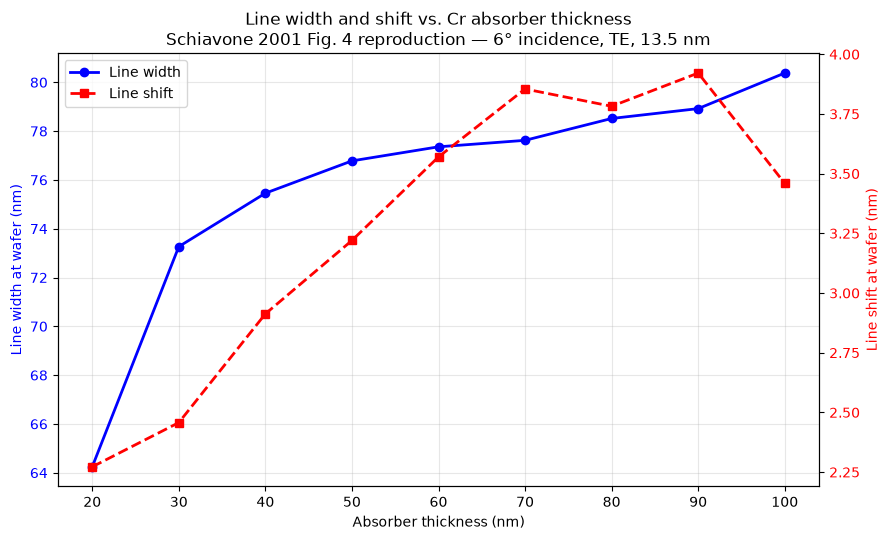

In [16]:
fig, ax1 = plt.subplots(figsize=(9, 5.5))

ax1.plot(df_fig4.thickness_nm, df_fig4.width_wafer_nm, 'b-o', lw=2, ms=6, label='Line width')
ax1.set_xlabel('Absorber thickness (nm)')
ax1.set_ylabel('Line width at wafer (nm)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_fig4.thickness_nm, df_fig4.shift_wafer_nm, 'r--s', lw=2, ms=6, label='Line shift')
ax2.set_ylabel('Line shift at wafer (nm)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax1.set_title('Line width and shift vs. Cr absorber thickness\n'
              'Schiavone 2001 Fig. 4 reproduction — 6° incidence, TE, 13.5 nm')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [17]:
def fmmax_full_stack_field(
    wavelength_nm=13.5,
    pitch_nm=840.0,
    line_width_nm=280.0,
    cr_thickness_nm=50.0,
    n_bilayers=40,
    d_mo_nm=2.78,
    d_si_nm=4.17,
    angle_deg=6.0,
    resolution_nm=2.0,
    approximate_num_terms=200,
    n_x_field_points=600,
    air_above_nm=60.0,
    n_z_air=24,
    n_z_cr=20,
    n_z_bilayer=2,
    polarization='TE',
):
    """Total field |E|^2 through the whole stack, on fmmax's native frame,
    returned with x re-centered so the Cr line is at x = 0."""
    n_air = 1.0 + 0.0j
    n_cr = get_n('Cr', wavelength_nm)
    n_mo = get_n('Mo', wavelength_nm)
    n_si = get_n('Si', wavelength_nm)
    eps_air = jnp.asarray(n_air**2, dtype=jnp.complex64)
    eps_cr = jnp.asarray(n_cr**2, dtype=jnp.complex64)
    eps_mo = jnp.asarray(n_mo**2, dtype=jnp.complex64)
    eps_si = jnp.asarray(n_si**2, dtype=jnp.complex64)

    nx = int(pitch_nm / resolution_nm)
    x_center = pitch_nm / 2.0

    plv = basis.LatticeVectors(
        u=jnp.asarray([pitch_nm, 0.0]), v=jnp.asarray([0.0, pitch_nm]),
    )
    xg, yg = basis.unit_cell_coordinates(
        primitive_lattice_vectors=plv, shape=(nx, nx),
    )
    density_cr = (jnp.abs(xg - x_center) <= line_width_nm / 2).astype(jnp.float32)
    eps_grating = utils.interpolate_permittivity(
        permittivity_solid=eps_cr, permittivity_void=eps_air, density=density_cr,
    )
    def uniform(e):
        return jnp.ones((nx, nx), dtype=jnp.complex64) * e

    permittivities = [uniform(eps_air), eps_grating]
    thicknesses = [jnp.asarray(air_above_nm), jnp.asarray(cr_thickness_nm)]
    for _ in range(n_bilayers):
        permittivities.append(uniform(eps_mo)); thicknesses.append(jnp.asarray(d_mo_nm))
        permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(d_si_nm))
    permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(0.0))

    k0 = 2 * jnp.pi / wavelength_nm
    kx = k0 * jnp.sin(jnp.deg2rad(angle_deg))
    in_plane_wavevector = jnp.asarray([kx, 0.0])

    expansion = basis.generate_expansion(
        primitive_lattice_vectors=plv,
        approximate_num_terms=approximate_num_terms,
        truncation=basis.Truncation.CIRCULAR,
    )
    layer_solve_results = [
        fmm.eigensolve_isotropic_media(
            wavelength=jnp.asarray(wavelength_nm),
            in_plane_wavevector=in_plane_wavevector,
            primitive_lattice_vectors=plv,
            permittivity=p, expansion=expansion,
            formulation=fmm.Formulation.FFT,
        )
        for p in permittivities
    ]
    s_int = scattering.stack_s_matrices_interior(
        layer_solve_results=layer_solve_results,
        layer_thicknesses=thicknesses,
    )

    n_terms = expansion.num_terms
    inc = jnp.zeros((2 * n_terms, 1), dtype=jnp.complex64)
    inc = inc.at[0 if polarization == 'TE' else n_terms, 0].set(1.0 + 0.0j)
    zero = jnp.zeros_like(inc)
    amps = fields.stack_amplitudes_interior(
        s_matrices_interior=s_int,
        forward_amplitude_0_start=inc,
        backward_amplitude_N_end=zero,
    )

    layer_znum = [n_z_air, n_z_cr] + [n_z_bilayer] * (2 * n_bilayers) + [1]

    x_eval = jnp.linspace(0.0, pitch_nm, n_x_field_points, endpoint=False)
    y_eval = jnp.zeros_like(x_eval)

    ef, hf, (x_out, y_out, z_out) = fields.stack_fields_3d_on_coordinates(
        amplitudes_interior=amps,
        layer_solve_results=layer_solve_results,
        layer_thicknesses=thicknesses,
        layer_znum=layer_znum,
        x=x_eval, y=y_eval,
    )

    Ex, Ey, Ez = ef[0, :, :, 0], ef[1, :, :, 0], ef[2, :, :, 0]
    I2d = np.abs(np.array(Ex))**2 + np.abs(np.array(Ey))**2 + np.abs(np.array(Ez))**2
    return I2d, np.array(x_out) - x_center, np.array(z_out), n_terms

print("Computing full-stack field for hero map...")
I_hero, x_hero, z_hero, nt_hero = fmmax_full_stack_field(
    cr_thickness_nm=50.0, approximate_num_terms=200,
)
print(f"  I shape {I_hero.shape}, N={nt_hero}")
print(f"  x range [{x_hero.min():.0f}, {x_hero.max():.0f}] nm")
print(f"  z range [{z_hero.min():.0f}, {z_hero.max():.0f}] nm")

Computing full-stack field for hero map...
  I shape (600, 205), N=193
  x range [-420, 419] nm
  z range [0, 388] nm


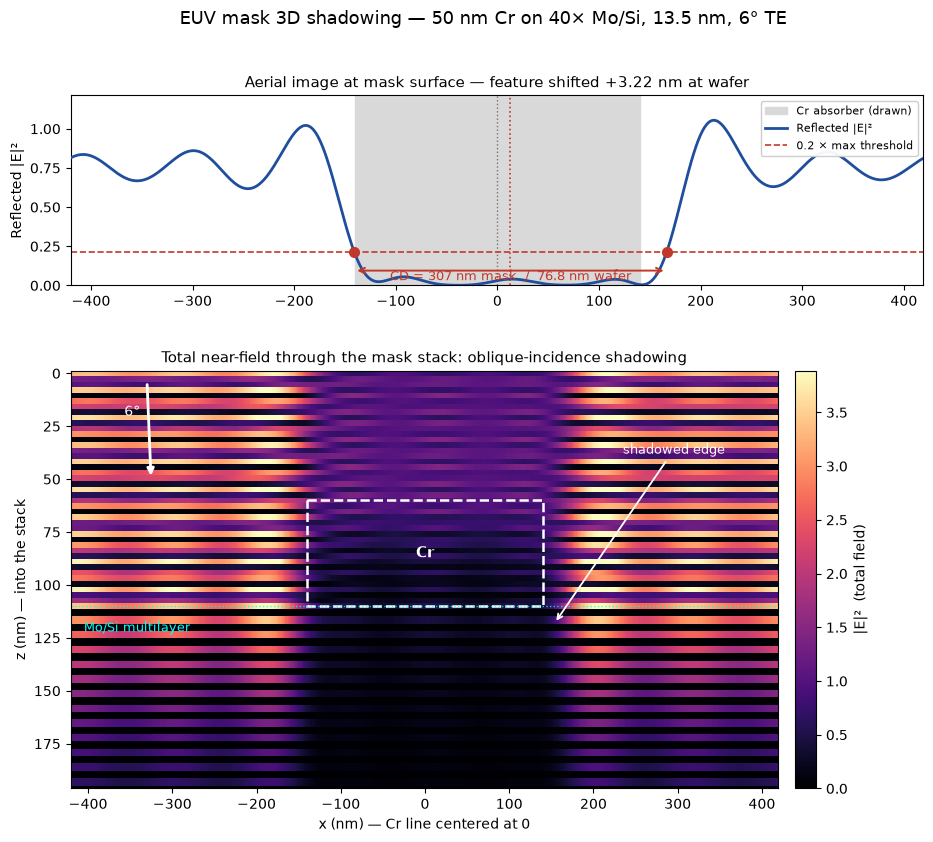

Saved to figures/hero_shadowing.png


In [19]:
fig = plt.figure(figsize=(11, 9))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 2.2], hspace=0.28)

AIR_TOP = 60.0
CR_BOT = AIR_TOP + 50.0
HALF_W = 140.0

# --- Panel A: reflected-only aerial image ---
I_ref, x_ref, z_ref, _ = fmmax_reflected_field(
    cr_thickness_nm=50.0, approximate_num_terms=200,
    resolution_nm=2.0, n_x_field_points=800,
)
I1d_ref = I_ref[:, np.argmin(np.abs(z_ref - z_ref.max()))]
w, s, le, re, th = extract_line_metrics(I1d_ref, x_ref)

ax0 = fig.add_subplot(gs[0])
ax0.fill_between([-HALF_W, HALF_W], 0, I1d_ref.max()*1.15,
                 color='0.85', zorder=0, label='Cr absorber (drawn)')
ax0.plot(x_ref, I1d_ref, color='#1f4e9c', lw=2, zorder=3, label='Reflected |E|²')
ax0.axhline(th, color='#c0392b', ls='--', lw=1.2, zorder=2, label='0.2 × max threshold')
ax0.plot([le, re], [th, th], 'o', color='#c0392b', ms=7, zorder=4)
ax0.annotate('', xy=(le, th*0.45), xytext=(re, th*0.45),
             arrowprops=dict(arrowstyle='<->', color='#c0392b', lw=1.4))
ax0.text((le+re)/2, th*0.16, f'CD = {w:.0f} nm mask  /  {w/4:.1f} nm wafer',
         ha='center', color='#c0392b', fontsize=9)
ax0.axvline(0, color='0.45', ls=':', lw=1, zorder=1)
ax0.axvline(s, color='#c0392b', ls=':', lw=1.2, zorder=1)
ax0.set_xlim(x_ref.min(), x_ref.max())
ax0.set_ylim(0, I1d_ref.max()*1.15)
ax0.set_ylabel('Reflected |E|²')
ax0.set_title(f'Aerial image at mask surface — feature shifted {s/4:+.2f} nm at wafer',
              fontsize=11)
ax0.legend(fontsize=8, loc='upper right', framealpha=0.95)

# --- Panel B: total field through stack ---
ax1 = fig.add_subplot(gs[1])
zmax_plot = 200.0
zsel = z_hero <= zmax_plot
im = ax1.pcolormesh(x_hero, z_hero[zsel], I_hero[:, zsel].T,
                    cmap='magma', shading='auto',
                    vmin=0, vmax=np.percentile(I_hero[:, zsel], 99.5))
ax1.invert_yaxis()
cb = fig.colorbar(im, ax=ax1, pad=0.02)
cb.set_label('|E|²  (total field)')

ax1.add_patch(plt.Rectangle((-HALF_W, AIR_TOP), 2*HALF_W, 50.0,
                            fill=False, ec='white', lw=1.8, ls='--'))
ax1.text(0, AIR_TOP+25, 'Cr', color='white', ha='center', va='center',
         fontsize=11, weight='bold')
ax1.axhline(CR_BOT, color='cyan', lw=1, ls=':', alpha=0.8)
ax1.text(x_hero.min()+15, CR_BOT+12, 'Mo/Si multilayer', color='cyan', fontsize=9)

# illumination arrow at 6 deg
x0, z0, L = -330, 4, 46
ax1.annotate('', xy=(x0 + L*np.sin(np.deg2rad(6)), z0 + L*np.cos(np.deg2rad(6))),
             xytext=(x0, z0),
             arrowprops=dict(arrowstyle='-|>', color='white', lw=2))
ax1.text(x0-8, z0+16, '6°', color='white', fontsize=10, ha='right')

# shadow callout on the trailing edge
ax1.annotate('shadowed edge', xy=(HALF_W+14, CR_BOT+8), xytext=(HALF_W+95, AIR_TOP-22),
             color='white', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='white', lw=1.3))

ax1.set_xlabel('x (nm) — Cr line centered at 0')
ax1.set_ylabel('z (nm) — into the stack')
ax1.set_title('Total near-field through the mask stack: oblique-incidence shadowing',
              fontsize=11)

fig.suptitle('EUV mask 3D shadowing — 50 nm Cr on 40× Mo/Si, 13.5 nm, 6° TE',
             fontsize=13, y=0.975)
plt.savefig('/Users/yeshudanbora/euv-rcwa-inverse/figures/hero_shadowing.png',
            dpi=200, bbox_inches='tight')
plt.show()
print("Saved to figures/hero_shadowing.png")

/var/folders/f8/s56mn9q94jvf6815bst06_br0000gn/T/ipykernel_26175/2166430216.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


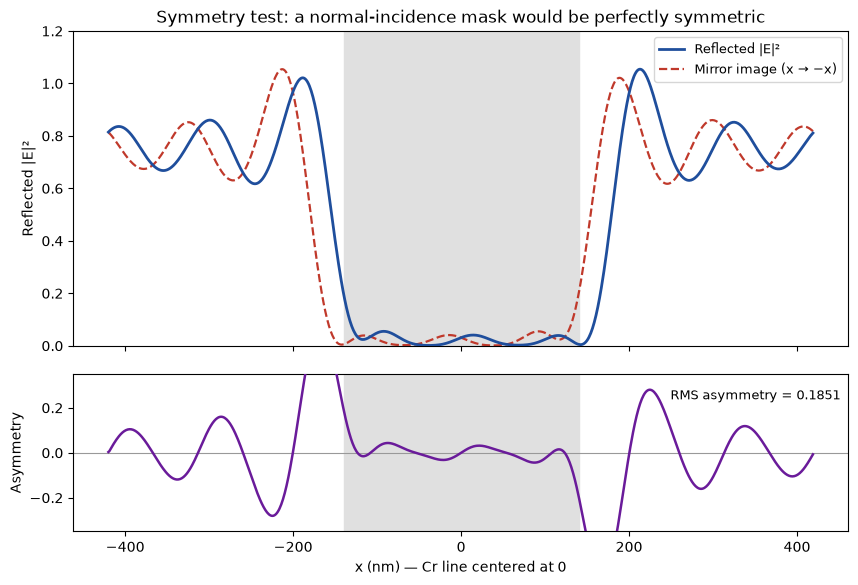

In [20]:
I1d = I_ref[:, np.argmin(np.abs(z_ref - z_ref.max()))]
I_mirror = np.interp(x_ref, -x_ref[::-1], I1d[::-1])

fig, (axA, axB) = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.12})

axA.fill_between([-140, 140], 0, 1.2, color='0.88', zorder=0)
axA.plot(x_ref, I1d, color='#1f4e9c', lw=2, label='Reflected |E|²', zorder=3)
axA.plot(x_ref, I_mirror, color='#c0392b', lw=1.6, ls='--',
         label='Mirror image (x → −x)', zorder=2)
axA.set_ylabel('Reflected |E|²')
axA.set_ylim(0, 1.2)
axA.legend(fontsize=9)
axA.set_title('Symmetry test: a normal-incidence mask would be perfectly symmetric')

axB.axhline(0, color='0.6', lw=0.8)
axB.fill_between([-140, 140], -0.35, 0.35, color='0.88', zorder=0)
axB.plot(x_ref, I1d - I_mirror, color='#6a1b9a', lw=1.8, zorder=3)
axB.set_ylabel('Asymmetry')
axB.set_xlabel('x (nm) — Cr line centered at 0')
axB.set_ylim(-0.35, 0.35)

rms = np.sqrt(np.mean((I1d - I_mirror)**2))
axB.text(0.99, 0.9, f'RMS asymmetry = {rms:.4f}', transform=axB.transAxes,
         ha='right', va='top', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/yeshudanbora/euv-rcwa-inverse/figures/asymmetry.png',
            dpi=200, bbox_inches='tight')
plt.show()

In [21]:
print(f"{'angle':>7}  {'width_mask':>11}  {'shift_mask':>11}  {'shift_wafer':>12}  {'RMS asym':>9}")
print("-" * 58)
for ang in [0.0, 2.0, 4.0, 6.0, 8.0, 10.0]:
    I_a, x_a, z_a, _ = fmmax_reflected_field(
        cr_thickness_nm=50.0, angle_deg=ang,
        approximate_num_terms=200, resolution_nm=2.0, n_x_field_points=800,
    )
    I1d_a = I_a[:, np.argmin(np.abs(z_a - z_a.max()))]
    w_a, s_a, _, _, _ = extract_line_metrics(I1d_a, x_a)
    mir = np.interp(x_a, -x_a[::-1], I1d_a[::-1])
    rms_a = np.sqrt(np.mean((I1d_a - mir)**2))
    print(f"{ang:>6.1f}°  {w_a:>11.2f}  {s_a:>+11.2f}  {s_a/4:>+12.3f}  {rms_a:>9.4f}")

  angle   width_mask   shift_mask   shift_wafer   RMS asym
----------------------------------------------------------
   0.0°       304.91        -0.00        -0.000     0.0000
   2.0°       305.13        +4.11        +1.028     0.0707
   4.0°       305.71        +8.36        +2.090     0.1362
   6.0°       307.12       +12.88        +3.220     0.1851
   8.0°       311.40       +16.98        +4.245     0.2235
  10.0°       314.92       +22.37        +5.592     0.2535


In [22]:
print(f"{'t_Cr':>6}  {'shift_mask':>11}  {'shadow':>8}  {'eff.depth':>10}")
print("-" * 40)
for t in [20, 50, 80, 100]:
    I_t, x_t, z_t, _ = fmmax_reflected_field(
        cr_thickness_nm=float(t), angle_deg=6.0,
        approximate_num_terms=200, resolution_nm=2.0, n_x_field_points=800,
    )
    I1d_t = I_t[:, np.argmin(np.abs(z_t - z_t.max()))]
    _, s_t, _, _, _ = extract_line_metrics(I1d_t, x_t)
    shadow = 2 * s_t
    eff_depth = shadow / np.tan(np.deg2rad(6.0))
    print(f"{t:>6}  {s_t:>+11.2f}  {shadow:>8.1f}  {eff_depth:>10.1f}")

  t_Cr   shift_mask    shadow   eff.depth
----------------------------------------
    20        +9.09      18.2       172.9
    50       +12.88      25.8       245.1
    80       +15.13      30.3       287.9
   100       +13.84      27.7       263.3


In [23]:
for mat in ['Ru', 'TaBN']:
    n = get_n(mat, 13.5)
    print(f"n({mat}, 13.5 nm) = {n:.4f}, β = {n.imag:.4f}")

n(Ru, 13.5 nm) = 0.8864+0.0171j, β = 0.0171
n(TaBN, 13.5 nm) = 0.9286+0.0381j, β = 0.0381


In [25]:
def fmmax_reflected_field_modern(
    wavelength_nm=13.5,
    pitch_nm=840.0,
    line_width_nm=280.0,
    absorber_material='TaBN',
    absorber_thickness_nm=60.0,
    ru_cap_nm=2.5,
    n_bilayers=40,
    d_mo_nm=2.78,
    d_si_nm=4.17,
    angle_deg=6.0,
    resolution_nm=2.0,
    approximate_num_terms=200,
    n_x_field_points=800,
    air_above_nm=20.0,
    polarization='TE',
):
    """Modern EUV mask: patterned absorber on Ru-capped Mo/Si multilayer.
    Ru cap is blanket (unpatterned) — it's an etch stop, stays under the absorber."""
    n_air = 1.0 + 0.0j
    n_abs = get_n(absorber_material, wavelength_nm)
    n_ru = get_n('Ru', wavelength_nm)
    n_mo = get_n('Mo', wavelength_nm)
    n_si = get_n('Si', wavelength_nm)
    eps_air = jnp.asarray(n_air**2, dtype=jnp.complex64)
    eps_abs = jnp.asarray(n_abs**2, dtype=jnp.complex64)
    eps_ru = jnp.asarray(n_ru**2, dtype=jnp.complex64)
    eps_mo = jnp.asarray(n_mo**2, dtype=jnp.complex64)
    eps_si = jnp.asarray(n_si**2, dtype=jnp.complex64)

    nx = int(pitch_nm / resolution_nm)
    x_center = pitch_nm / 2.0
    plv = basis.LatticeVectors(
        u=jnp.asarray([pitch_nm, 0.0]), v=jnp.asarray([0.0, pitch_nm]),
    )
    xg, yg = basis.unit_cell_coordinates(
        primitive_lattice_vectors=plv, shape=(nx, nx),
    )
    density = (jnp.abs(xg - x_center) <= line_width_nm / 2).astype(jnp.float32)
    eps_grating = utils.interpolate_permittivity(
        permittivity_solid=eps_abs, permittivity_void=eps_air, density=density,
    )
    def uniform(e):
        return jnp.ones((nx, nx), dtype=jnp.complex64) * e

    permittivities = [uniform(eps_air), eps_grating, uniform(eps_ru)]
    thicknesses = [jnp.asarray(air_above_nm),
                   jnp.asarray(absorber_thickness_nm),
                   jnp.asarray(ru_cap_nm)]
    for _ in range(n_bilayers):
        permittivities.append(uniform(eps_mo)); thicknesses.append(jnp.asarray(d_mo_nm))
        permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(d_si_nm))
    permittivities.append(uniform(eps_si)); thicknesses.append(jnp.asarray(0.0))

    k0 = 2 * jnp.pi / wavelength_nm
    kx = k0 * jnp.sin(jnp.deg2rad(angle_deg))
    in_plane_wavevector = jnp.asarray([kx, 0.0])
    expansion = basis.generate_expansion(
        primitive_lattice_vectors=plv,
        approximate_num_terms=approximate_num_terms,
        truncation=basis.Truncation.CIRCULAR,
    )
    layer_solve_results = [
        fmm.eigensolve_isotropic_media(
            wavelength=jnp.asarray(wavelength_nm),
            in_plane_wavevector=in_plane_wavevector,
            primitive_lattice_vectors=plv,
            permittivity=p, expansion=expansion,
            formulation=fmm.Formulation.FFT,
        )
        for p in permittivities
    ]
    s_int = scattering.stack_s_matrices_interior(
        layer_solve_results=layer_solve_results,
        layer_thicknesses=thicknesses,
    )
    n_terms = expansion.num_terms
    inc = jnp.zeros((2 * n_terms, 1), dtype=jnp.complex64)
    inc = inc.at[0 if polarization == 'TE' else n_terms, 0].set(1.0 + 0.0j)
    zero = jnp.zeros_like(inc)
    amps = fields.stack_amplitudes_interior(
        s_matrices_interior=s_int,
        forward_amplitude_0_start=inc,
        backward_amplitude_N_end=zero,
    )
    fwd_top, bwd_top = amps[0]
    fwd_zeroed = jnp.zeros_like(fwd_top)

    x_eval = jnp.linspace(0.0, pitch_nm, n_x_field_points, endpoint=False)
    y_eval = jnp.zeros_like(x_eval)
    ef, hf, (x_out, y_out, z_out) = fields.layer_fields_3d_on_coordinates(
        forward_amplitude_start=fwd_zeroed,
        backward_amplitude_end=bwd_top,
        layer_solve_result=layer_solve_results[0],
        layer_thickness=thicknesses[0],
        layer_znum=8,
        x=x_eval, y=y_eval,
    )
    Ex, Ey, Ez = ef[0, ..., 0], ef[1, ..., 0], ef[2, ..., 0]
    I2d = np.abs(np.array(Ex))**2 + np.abs(np.array(Ey))**2 + np.abs(np.array(Ez))**2
    return I2d, np.array(x_out) - x_center, np.array(z_out), n_terms

# Modern stack thickness sweep
print("Modern stack: TaBN absorber on Ru-capped Mo/Si\n")
print(f"{'t_TaBN':>7}  {'width_mask':>11}  {'shift_mask':>11}  {'width_wafer':>12}  {'shift_wafer':>12}")
print("-" * 62)
modern = []
for t in [20, 30, 40, 50, 60, 70, 80, 90, 100]:
    I_m, x_m, z_m, _ = fmmax_reflected_field_modern(absorber_thickness_nm=float(t))
    I1d_m = I_m[:, np.argmin(np.abs(z_m - z_m.max()))]
    w_m, s_m, _, _, _ = extract_line_metrics(I1d_m, x_m)
    modern.append({'thickness_nm': t, 'width_mask_nm': w_m, 'shift_mask_nm': s_m,
                   'width_wafer_nm': w_m/4, 'shift_wafer_nm': s_m/4})
    print(f"{t:>7}  {w_m:>11.2f}  {s_m:>+11.2f}  {w_m/4:>12.2f}  {s_m/4:>+12.2f}")

df_modern = pd.DataFrame(modern)

Modern stack: TaBN absorber on Ru-capped Mo/Si

 t_TaBN   width_mask   shift_mask   width_wafer   shift_wafer
--------------------------------------------------------------
     20          nan         +nan           nan          +nan
     30       287.42        +9.89         71.85         +2.47
     40       296.74       +12.29         74.18         +3.07
     50       307.02       +12.99         76.76         +3.25
     60       307.57       +15.66         76.89         +3.92
     70       312.08       +15.76         78.02         +3.94
     80       311.07       +18.02         77.77         +4.51
     90       316.88       +16.84         79.22         +4.21
    100       318.30       +17.69         79.58         +4.42


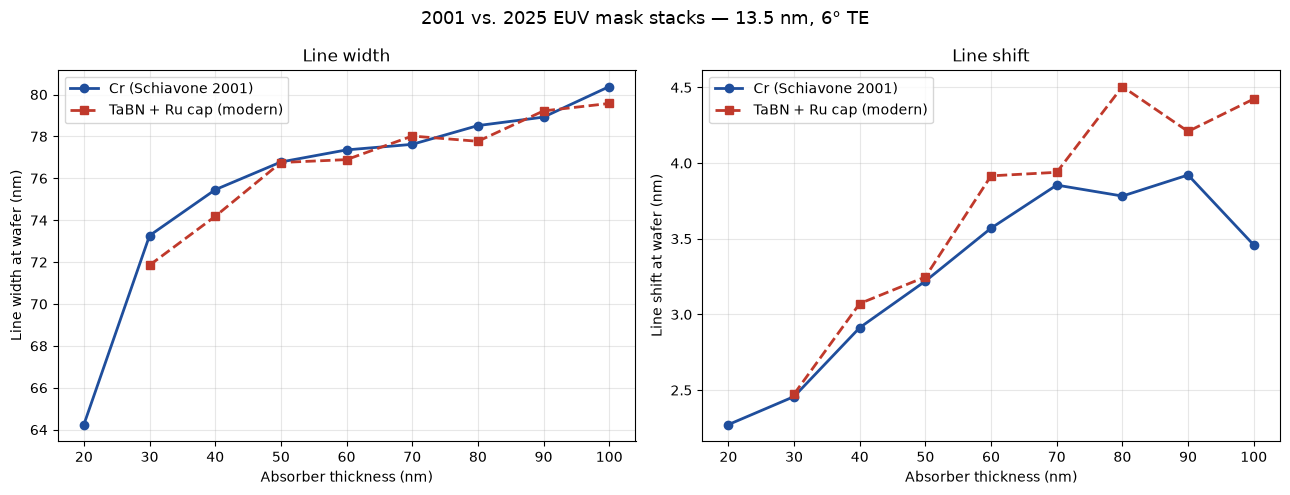

In [26]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

axL.plot(df_fig4.thickness_nm, df_fig4.width_wafer_nm, 'o-', color='#1f4e9c',
         lw=2, label='Cr (Schiavone 2001)')
axL.plot(df_modern.thickness_nm, df_modern.width_wafer_nm, 's--', color='#c0392b',
         lw=2, label='TaBN + Ru cap (modern)')
axL.set_xlabel('Absorber thickness (nm)')
axL.set_ylabel('Line width at wafer (nm)')
axL.set_title('Line width')
axL.legend(); axL.grid(alpha=0.3)

axR.plot(df_fig4.thickness_nm, df_fig4.shift_wafer_nm, 'o-', color='#1f4e9c',
         lw=2, label='Cr (Schiavone 2001)')
axR.plot(df_modern.thickness_nm, df_modern.shift_wafer_nm, 's--', color='#c0392b',
         lw=2, label='TaBN + Ru cap (modern)')
axR.set_xlabel('Absorber thickness (nm)')
axR.set_ylabel('Line shift at wafer (nm)')
axR.set_title('Line shift')
axR.legend(); axR.grid(alpha=0.3)

fig.suptitle('2001 vs. 2025 EUV mask stacks — 13.5 nm, 6° TE', fontsize=13)
plt.tight_layout()
plt.savefig('/Users/yeshudanbora/euv-rcwa-inverse/figures/era_comparison.png',
            dpi=200, bbox_inches='tight')
plt.show()